# Méthode creuse

Dans cette première partie, nous allons étudier les données et mettre en place une première méthode de recherche dite creuse.

## Chargement des bibliothèques nécessaires

In [ ]:
import json
import numpy as np
import re
import matplotlib.pyplot as plt

from collections import defaultdict, Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


import warnings

warnings.filterwarnings("ignore")

# For embeddings and similarity computation
try:
    from sklearn.metrics.pairwise import cosine_similarity

    print("Required libraries imported successfully!")
except ImportError as e:
    print(f"Missing library: {e}")
    print(
        "Please install with: pip install sentence-transformers scikit-learn networkx"
    )

Required libraries imported successfully!


## Chargement des Corpus

In [ ]:
def load_corpus(file_path: str) -> dict[str, dict]:
    """
    Load corpus data from JSONL file.
    Returns dictionary mapping document IDs to document data.
    """
    corpus = {}
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            obj = json.loads(line)
            docid = str(obj["_id"])
            corpus[docid] = obj
    return corpus


def load_queries(file_path: str) -> dict[str, dict]:
    """
    Load query data from JSONL file.
    Returns dictionary mapping query IDs to query data.
    """
    queries = {}
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            obj = json.loads(line)
            qid = str(obj["_id"])
            queries[qid] = obj
    return queries


def load_qrels(file_path: str) -> dict[str, dict[str, int]]:
    """
    Load relevance judgments from TSV file.
    Returns dictionary mapping query IDs to candidate relevance scores.
    """
    qrels = defaultdict(dict)
    with open(file_path, "r") as f:
        lines = f.readlines()
        for line in lines[1:]:
            qid, docid, score = line.strip().split("\t")
            qrels[qid][docid] = int(score)
    return qrels


print("Loading dataset...")
corpus = load_corpus("./data/corpus.jsonl")
queries = load_queries("./data/queries.jsonl")
qrels_valid = load_qrels("./data/valid.tsv")


print(f"Loaded {len(corpus)} documents in corpus")
print(f"Loaded {len(queries)} queries")
print(f"Loaded relevance for {len(qrels_valid)} queries (dataset)")

Loading dataset...
Loaded 25657 documents in corpus
Loaded 1000 queries
Loaded relevance for 700 queries (dataset)
Loaded relevance for 300 queries (dataset)


## Etude de la pertinence des requêtes

Afin d'étudier les documents que nosu avons commencé par estimer le rapport de documents utiles des requêtes

In [ ]:
def calculate_average_proportions(
    qrels: dict[str, dict[str, int]],
) -> tuple[float, float]:
    """
    Calculate the proportion of relevant documents in average across all queries.
    """
    total_relevant = 0
    total_irrelevant = 0
    total_documents = 0

    for _, doc_scores in qrels.items():
        relevant_docs = sum(1 for score in doc_scores.values() if score == 1)
        irrelevant_docs = sum(1 for score in doc_scores.values() if score == 0)
        total_relevant += relevant_docs
        total_irrelevant += irrelevant_docs
        total_documents += len(doc_scores)

    avg_proportion_relevant = (
        total_relevant / total_documents if total_documents > 0 else 0
    )
    avg_proportion_irrelevant = (
        total_irrelevant / total_documents if total_documents > 0 else 0
    )

    return avg_proportion_relevant, avg_proportion_irrelevant


avg_proportion_relevant, avg_proportion_irrelevant = calculate_average_proportions(
    qrels_valid
)
print(
    f"Average proportion of relevant documents across all queries: {avg_proportion_relevant:.4f}"
)
print(
    f"Average proportion of irrelevant documents across all queries: {avg_proportion_irrelevant:.4f}"
)

## Mise en oeuvre de fonctions tests

Ces fonctions servent pour nous à apprendre à étudier les données que nous avons, les données sortis ne nous pas forcément utiles pour la suite de l'étude.

In [ ]:
def fetch_query_data(
    query_id: str,
    qrels: dict[str, dict[str, int]],
    queries: dict[str, dict],
    corpus: dict[str, dict],
) -> dict:
    """
    Fetch query text and associated metadata given a query ID.
    """
    if query_id not in queries:
        raise ValueError(f"Query ID {query_id} not found in queries.")
    linked_documents = qrels.get(query_id, {})
    query_data = {
        "query": queries[query_id],
        "linked_documents": {"relevant": [], "irrelevant": []},
    }
    for doc_id in linked_documents:
        if doc_id in corpus:
            doc_data = corpus[doc_id]
            if linked_documents[doc_id] == 1:
                query_data["linked_documents"]["relevant"].append(doc_data)
            else:
                query_data["linked_documents"]["irrelevant"].append(doc_data)
    return query_data


first_id = list(queries.keys())[0]

query_data = fetch_query_data(first_id, qrels_valid, queries, corpus)
print(f"Query ID: {first_id}")
print(f"Query Text: {query_data['query']['text']}")
print(
    f"Number of Relevant Documents: {len(query_data['linked_documents']['relevant'])}"
)
print(
    f"Number of Irrelevant Documents: {len(query_data['linked_documents']['irrelevant'])}"
)
relevant_titles = [doc["title"] for doc in query_data["linked_documents"]["relevant"]]
irrelevant_titles = [
    doc["title"] for doc in query_data["linked_documents"]["irrelevant"]
]
relevant_titles_str = "\n".join(relevant_titles)
irrelevant_titles_str = "\n".join(irrelevant_titles)
print(f"Relevant Document Titles:\n{relevant_titles_str}\n")
print(f"Irrelevant Document Titles:\n{irrelevant_titles_str}")

## Etude statistiques de l'apparition des mots

Nous nous sommes d'abord intéressé au taux d'apparition des mots dans le corpus en prenant en compte le titre et le texte.

In [8]:
vectorizer = CountVectorizer(
    stop_words="english",
    lowercase=True,
    token_pattern=r"\b\w{3,}\b",
)


def compute_term_document_matrix(corpus: dict[str, dict]) -> np.ndarray:
    """
    Compute the term-document matrix for the given corpus.
    Each row corresponds to a document, and each column corresponds to a term.
    The value at (i, j) represents the frequency of term j in document i.
    """
    documents = [
        f"{doc_data['title']} {doc_data['text']}" for doc_id, doc_data in corpus.items()
    ]
    term_document_matrix = vectorizer.fit_transform(documents)
    return term_document_matrix.toarray()


term_document_matrix = compute_term_document_matrix(corpus)

### Graohe de distribution des mots

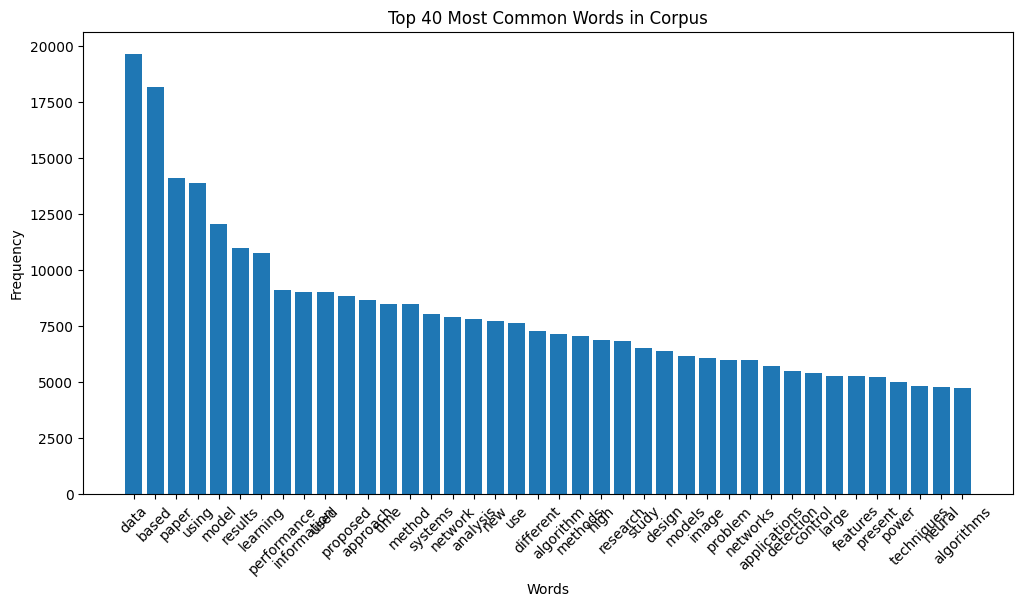

In [9]:
def plot_word_distribution(term_document_matrix: np.ndarray, top_n: int = 20):
    """
    Plot the distribution of the most common words in the corpus.
    """

    word_counts = np.sum(term_document_matrix, axis=0)
    terms = vectorizer.get_feature_names_out()
    word_count_dict = dict(zip(terms, word_counts))
    most_common_words = Counter(word_count_dict).most_common(top_n)
    words, counts = zip(*most_common_words)

    plt.figure(figsize=(12, 6))
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.title(f"Top {top_n} Most Common Words in Corpus")
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.show()


plot_word_distribution(term_document_matrix, top_n=40)

## Création de la matrice

In [11]:
# ==========================================
# 1. CONFIGURATION DES POIDS (Ajustables)
# ==========================================
MY_WEIGHTS = {
    "title": 1,  # Importance du titre
    "text": 1,  # Base (texte du résumé)
    "authors": 10,  # Importance d'un auteur commun
    "references": 10,  # Importance d'une référence commune
    "cited_by": 1,  # Importance d'une citation commune
    "year": 1,  # Importance de l'année
}


# ==========================================
# 2. FONCTIONS DE PRÉPARATION (TEXT ENRICHMENT)
# ==========================================
def get_weighted_text(doc_data, weights):
    """Transforme un dictionnaire (doc ou query) en texte pondéré."""
    metadata = doc_data.get("metadata", {})

    # Préparation des segments avec répétition selon les poids
    # On ajoute un espace final pour éviter la fusion de mots
    t = (str(doc_data.get("title", "")) + " ") * weights.get("title", 1)
    txt = (str(doc_data.get("text", "")) + " ") * weights.get("text", 1)

    # Métadonnées avec préfixes pour éviter les collisions avec le texte
    auths = " ".join([f"AUTH_{a}" for a in metadata.get("authors", [])])
    auth_tokens = (auths + " ") * weights.get("authors", 1)

    refs = " ".join([f"REF_{r}" for r in metadata.get("references", [])])
    ref_tokens = (refs + " ") * weights.get("references", 1)

    cites = " ".join([f"CITE_{c}" for c in metadata.get("cited_by", [])])
    cite_tokens = (cites + " ") * weights.get("cited_by", 1)

    y_val = metadata.get("year", "")
    year_token = (f"YEAR_{y_val} " if y_val else "") * weights.get("year", 1)

    return f"{t}{txt}{auth_tokens}{ref_tokens}{cite_tokens}{year_token}".strip()


# ==========================================
# 3. CRÉATION DE LA MATRICE
# ==========================================
def build_vectorizer_and_matrix(corpus, weights):
    """Initialise le vectorizer et crée la matrice TF-IDF enrichie."""
    # Pattern crucial : autorise les underscores et les chiffres pour nos tags
    custom_pattern = r"\b\w{2,}\b|AUTH_\w+|CITE_\w+|REF_\w+|YEAR_\w+"

    vectorizer = TfidfVectorizer(
        token_pattern=custom_pattern,
        max_df=1.0,  # Ne filtre pas les dates même si très fréquentes
        min_df=1,  # Ne filtre pas les auteurs même si uniques
    )

    # Transformation de tout le corpus en super-textes
    enriched_docs = [get_weighted_text(doc, weights) for doc in corpus.values()]

    # Apprentissage du vocabulaire et création de la matrice
    matrix = vectorizer.fit_transform(enriched_docs)

    return vectorizer, matrix


# ==========================================
# 4. MOTEUR DE RECHERCHE
# ==========================================
def first_search_engine(
    query_obj, corpus_subset, matrix_subset, vectorizer, weights, top_k=5
):
    """Recherche dans un sous-ensemble (candidats) avec les mêmes poids."""
    # 1. On transforme la requête avec EXACTEMENT la même logique de poids
    full_query = get_weighted_text(query_obj, weights)

    # 2. Vectorisation (transform uniquement, ne pas refaire de fit)
    query_vec = vectorizer.transform([full_query])

    # 3. Similarité Cosinus
    similarities = cosine_similarity(query_vec, matrix_subset)[0]

    # 4. Tri des résultats
    corpus_ids = list(corpus_subset.keys())
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    return [(corpus_ids[i], similarities[i]) for i in top_indices]


# ==========================================
# 5. ÉVALUATION
# ==========================================
def evaluate_enriched_engine(
    qrels_valid, queries, corpus, vectorizer, full_matrix, weights
):
    """Évalue les performances (Precision, Recall, F1)."""
    total_tp, total_fn, total_fp = 0, 0, 0
    corpus_ids = list(corpus.keys())

    for q_id, target_docs in qrels_valid.items():
        if q_id not in queries:
            continue

        # Isolation des 30-100 candidats du valid.tsv pour cette requête
        relevant_indices = [
            corpus_ids.index(d_id) for d_id in target_docs if d_id in corpus
        ]
        restricted_corpus = {
            d_id: corpus[d_id] for d_id in target_docs if d_id in corpus
        }
        restricted_matrix = full_matrix[relevant_indices]

        # Exécution de la recherche
        results = first_search_engine(
            queries[q_id],
            restricted_corpus,
            restricted_matrix,
            vectorizer,
            weights,
            top_k=5,
        )

        # Comptage des succès (hits)
        hits = sum(1 for d_id, score in results if target_docs.get(d_id, 0) == 1)
        total_relevant = sum(target_docs.values())

        total_tp += hits
        total_fn += total_relevant - hits
        total_fp += len(results) - hits

    # Métriques finales
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    f1 = (
        2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    print(f"\n--- RÉSULTATS (Poids: {weights}) ---")
    print(f"Rappel: {recall:.4f} | Précision: {precision:.4f} | F1-Score: {f1:.4f}")
    return f1


# ==========================================
# 6. LANCEMENT
# ==========================================

# A. Création de la matrice (à refaire si tu changes les poids)
vectorizer, enriched_matrix = build_vectorizer_and_matrix(corpus, MY_WEIGHTS)

# B. Lancement de l'évaluation
score = evaluate_enriched_engine(
    qrels_valid, queries, corpus, vectorizer, enriched_matrix, MY_WEIGHTS
)


--- RÉSULTATS (Poids: {'title': 1, 'text': 1, 'authors': 10, 'references': 10, 'cited_by': 1, 'year': 1}) ---
Rappel: 0.6991 | Précision: 0.6891 | F1-Score: 0.6941


### Mise en place du filtre

In [13]:
def build_vectorizer_and_matrix_filter(corpus, weights):
    custom_pattern = r"\b\w{2,}\b|AUTH_\w+|CITE_\w+|REF_\w+|YEAR_\w+"

    # --- Étape A : Génération des textes ---
    enriched_docs = [get_weighted_text(doc, weights) for doc in corpus.values()]

    # --- Étape B : Identification des 7 mots les plus fréquents ---
    # On utilise le même pattern que le vectorizer pour être cohérent
    all_tokens = []
    for doc in enriched_docs:
        all_tokens.extend(re.findall(custom_pattern, doc.lower()))

    counts = Counter(all_tokens)
    top_7_words = [word for word, _ in counts.most_common(7)]
    print(f"Mots les plus fréquents retirés : {top_7_words}")

    # --- Étape C : Initialisation avec filtres ---
    # min_df=2 retire automatiquement tous les mots qui n'apparaissent que dans 1 doc
    vectorizer = TfidfVectorizer(
        token_pattern=custom_pattern,
        stop_words=top_7_words,  # Retire les 7 plus fréquents
        min_df=2,  # Retire les mots apparaissant 1 seule fois
        max_df=1.0,  # On laisse max_df à 1.0 car on a déjà géré le top 7
    )

    matrix = vectorizer.fit_transform(enriched_docs)
    return vectorizer, matrix


# ==========================================
# EXÉCUTION
# ==========================================
# Recalcul de tout avec les nouveaux filtres
vectorizer, enriched_matrix = build_vectorizer_and_matrix_filter(corpus, MY_WEIGHTS)

evaluate_enriched_engine(
    qrels_valid, queries, corpus, vectorizer, enriched_matrix, MY_WEIGHTS
)

Mots les plus fréquents retirés : ['the', 'of', 'and', 'to', 'in', 'for', 'is']

--- RÉSULTATS (Poids: {'title': 1, 'text': 1, 'authors': 10, 'references': 10, 'cited_by': 1, 'year': 1}) ---
Rappel: 0.6757 | Précision: 0.6660 | F1-Score: 0.6708


0.6707913669064749

Nous observons donc que lors de la prise en compte de tous les paramètres (titre, texte, auteur, ...), nous avons des résultats légèrement moins bons.